## Classifier analyses

### Definitions
- iface (interface sequence) = interface sequence defined by first and last interacting residue in sequence
- overlap = total number of continuous overlapping residues between iface and fragment 
- `perc_interacting_residues`: percent of interacting residues in sequence over total number of interacting residues
- `perc_overlap_iface`: length of overlap over length of interface sequence
- `perc_overlap_fragment`: length of overlap over length of fragment
- `perc_fragment_iface`: length of fragment over length of interface sequence

### Criteria
- min. 5 contacts - fragment has at least 5 contacts (at least 5 residues in the interface defined)
- percentage of interacting residues: 40%, 50%, 80%
- percentage of overlapping between iface and fragment / fragment: 40%, 50%, 80%
- percentage of overlapping between iface and fragment / iface: 40%, 50%, 80%

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
sections = ['FD', 'AFminD (30)', 'AFminD (50)', 'AFminD (100)']
criteria = ['40% interacting residues', '50% interacting residues',
            '80% interacting residues', 'Min. 5 contacts']
confidence_scores = ['global_plddt', 'mean_plddt_A', 'mean_plddt_B', 'ptm',
       'iptm', 'combined_score', 'ipSAE_max', 'pDockQ_max', 'pDockQ2_max',
       'LIS_max', 'ipsae_A_B', 'pdockq2_A_B', 'lis_A_B', 'ipsae_B_A',
       'pdockq2_B_A', 'lis_B_A']
pyrosetta_scores = ['interface_dG', 'interface_SASA',
       'interface_dG_SASA_ratio', 'shape_complementarity',
       'num_interface_residues', 'buried_unsatisfied_hbonds', 'packstat',
       'binder_dG', 'binder_SASA']
electrostatics = ['idp_core_charged',
       'receptor_core_charged', 'idp_interface_charged',
       'receptor_interface_charged', 'idp_rim_charged', 'receptor_rim_charged',
       'idp_surface_charged', 'receptor_surface_charged',
       'idp_core_hydropathy', 'receptor_core_hydropathy',
       'idp_interface_hydropathy', 'receptor_interface_hydropathy',
       'idp_rim_hydropathy', 'receptor_rim_hydropathy',
       'idp_surface_hydropathy', 'receptor_surface_hydropathy',
       'idp_core_hydrophobic', 'receptor_core_hydrophobic',
       'idp_interface_hydrophobic', 'receptor_interface_hydrophobic',
       'idp_rim_hydrophobic', 'receptor_rim_hydrophobic',
       'idp_surface_hydrophobic', 'receptor_surface_hydrophobic',
       'idp_core_polar', 'receptor_core_polar', 'idp_interface_polar',
       'receptor_interface_polar', 'idp_rim_polar', 'receptor_rim_polar',
       'idp_surface_polar', 'receptor_surface_polar', 'idp_core_small',
       'receptor_core_small', 'idp_interface_small',
       'receptor_interface_small', 'idp_rim_small', 'receptor_rim_small',
       'idp_surface_small', 'receptor_surface_small']
all_features = confidence_scores + pyrosetta_scores + electrostatics

In [26]:
palette1 = sns.color_palette("bright")
print(palette1.as_hex())
palette1

['#023eff', '#ff7c00', '#1ac938', '#e8000b', '#8b2be2', '#9f4800', '#f14cc1', '#a3a3a3', '#ffc400', '#00d7ff']


[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
 (1.0, 0.7686274509803922, 0.0),
 (0.0, 0.8431372549019608, 1.0)]

In [27]:
model_colors = {"Logistic Regression": palette1[0],
                "XGBoost": palette1[1],
                "Gradient Boosting": palette1[2],
                "SVM": palette1[3],
                "Random Forest": palette1[4]}

In [59]:
# load entire dataset
df = pd.read_csv("./data/uniprot_idp_domain_receptor_full_dataset_v2.tsv", sep='\t')
classifier = pd.read_csv("classifier_training_parallel_models_v1.tsv", sep='\t')


C:\Users\Admin\AppData\Local\Temp\ipykernel_29344\2022300273.py:2: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/uniprot_idp_domain_receptor_full_dataset_v2.tsv", sep='\t')


In [17]:
section_by_criteria = classifier[['Section', 'Criteria', 'True Percentage', 'True Count']].drop_duplicates(ignore_index=True)
section_by_criteria[section_by_criteria['Criteria'].isin(criteria)]


,Section,Criteria,True Percentage,True Count
0,AFminD (100),40% interacting residues,0.032444,310
3,AFminD (100),50% interacting residues,0.027211,260
6,AFminD (100),80% interacting residues,0.014652,140
9,AFminD (100),Min. 5 contacts,0.065934,630
10,AFminD (30),40% interacting residues,0.014053,315
13,AFminD (30),50% interacting residues,0.010707,240
16,AFminD (30),80% interacting residues,0.004684,105
19,AFminD (30),Min. 5 contacts,0.032791,735
20,AFminD (50),40% interacting residues,0.019182,300
23,AFminD (50),50% interacting residues,0.016944,265


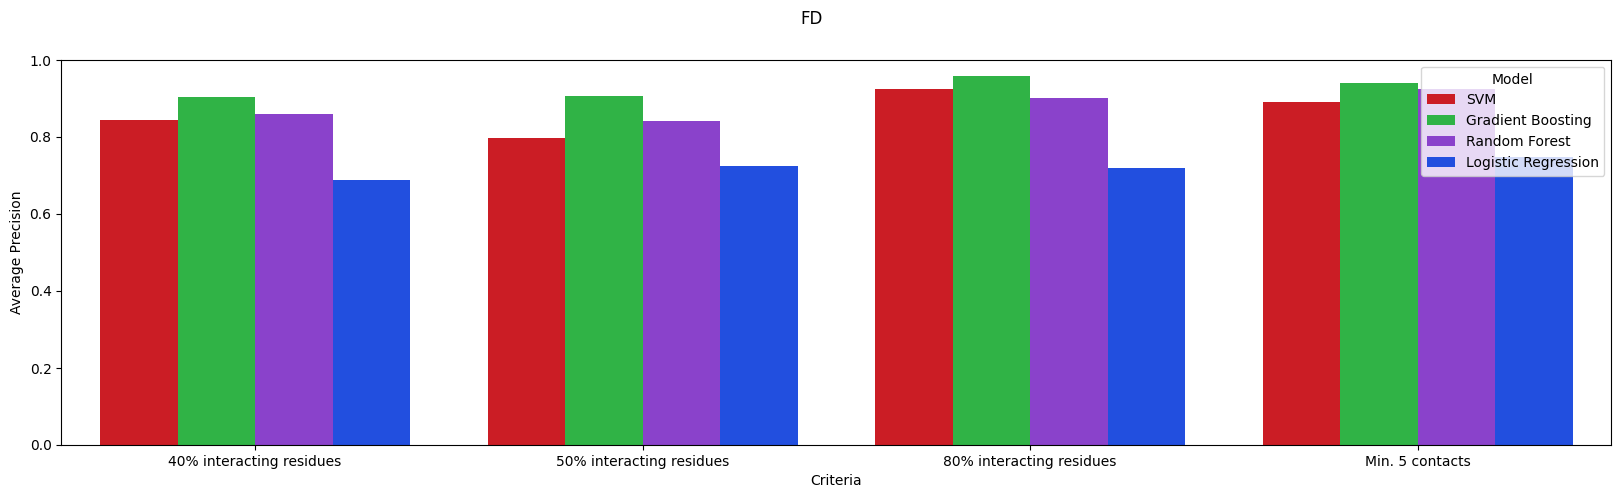

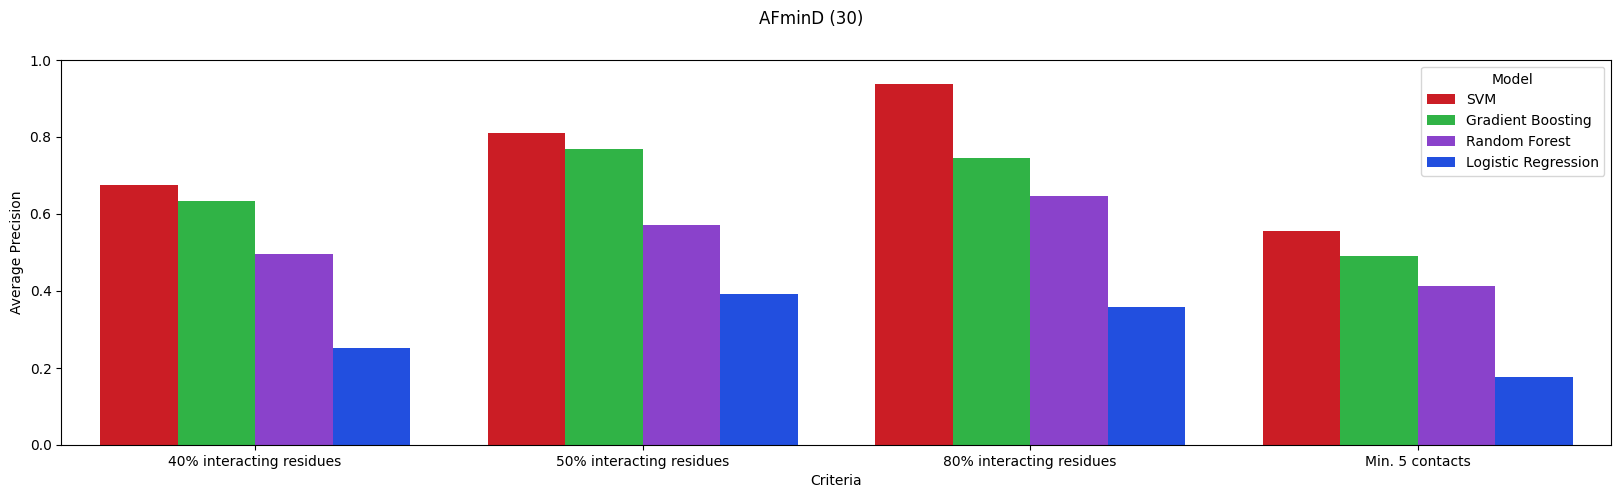

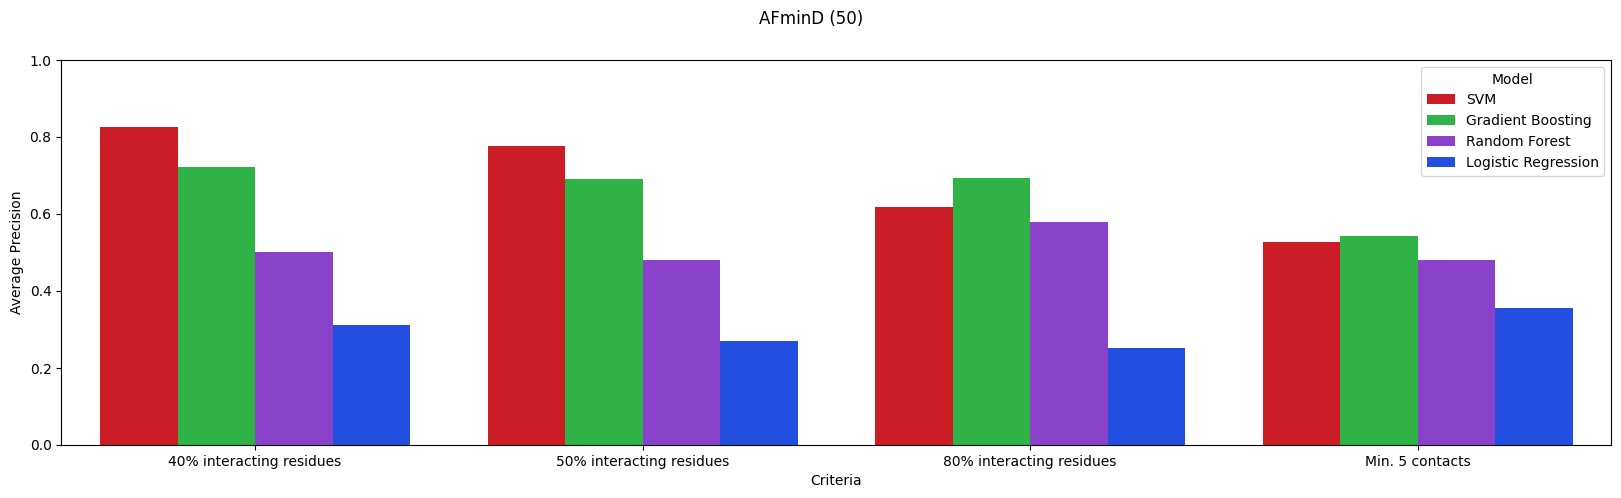

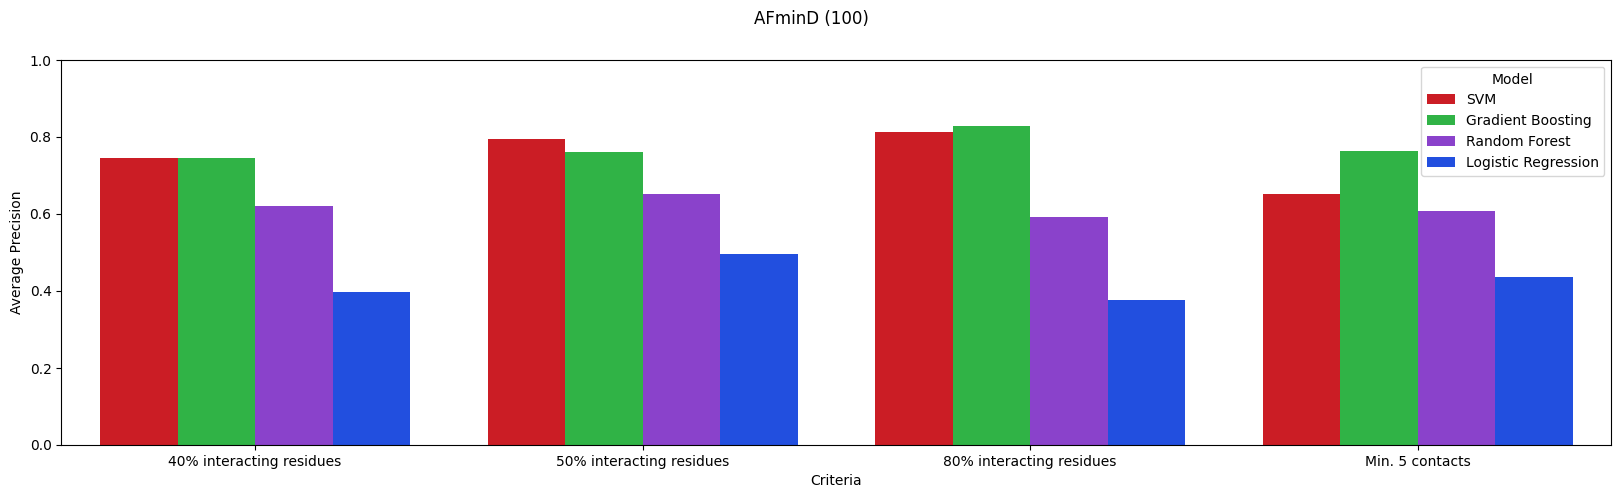

In [42]:
order = ['SVM', 'Gradient Boosting', 'Random Forest', 'Logistic Regression']
for sec in sections:
    test = classifier[(classifier['Section'] == sec) & (classifier['Criteria'].isin(criteria))]
    fig, ax = plt.subplots(figsize=(20,5))
    sns.barplot(data=test, x='Criteria', y='Average Precision', hue='Model', palette=model_colors, hue_order=order)
    ax.set_ylim(0,1)
    plt.suptitle(sec)

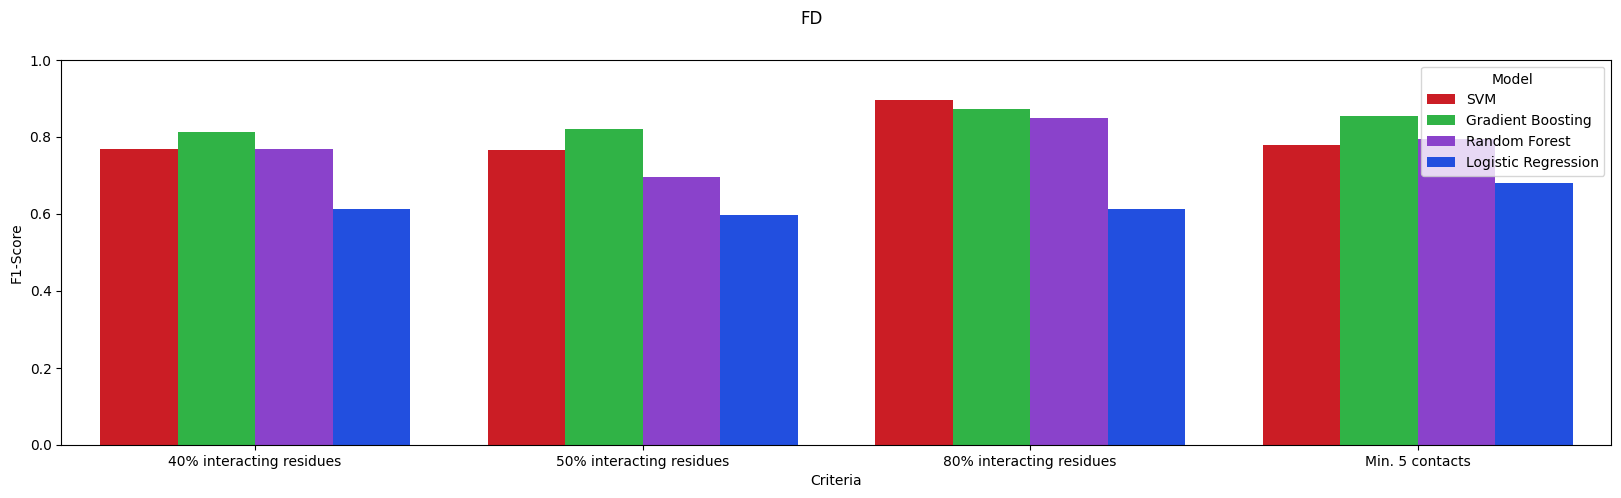

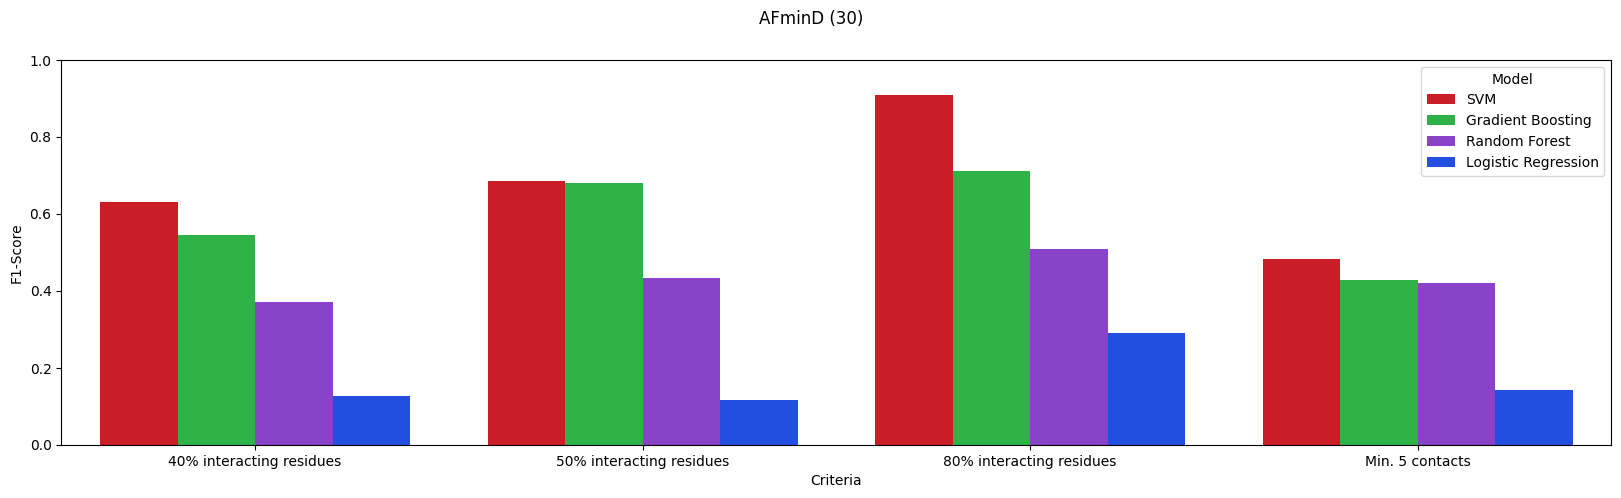

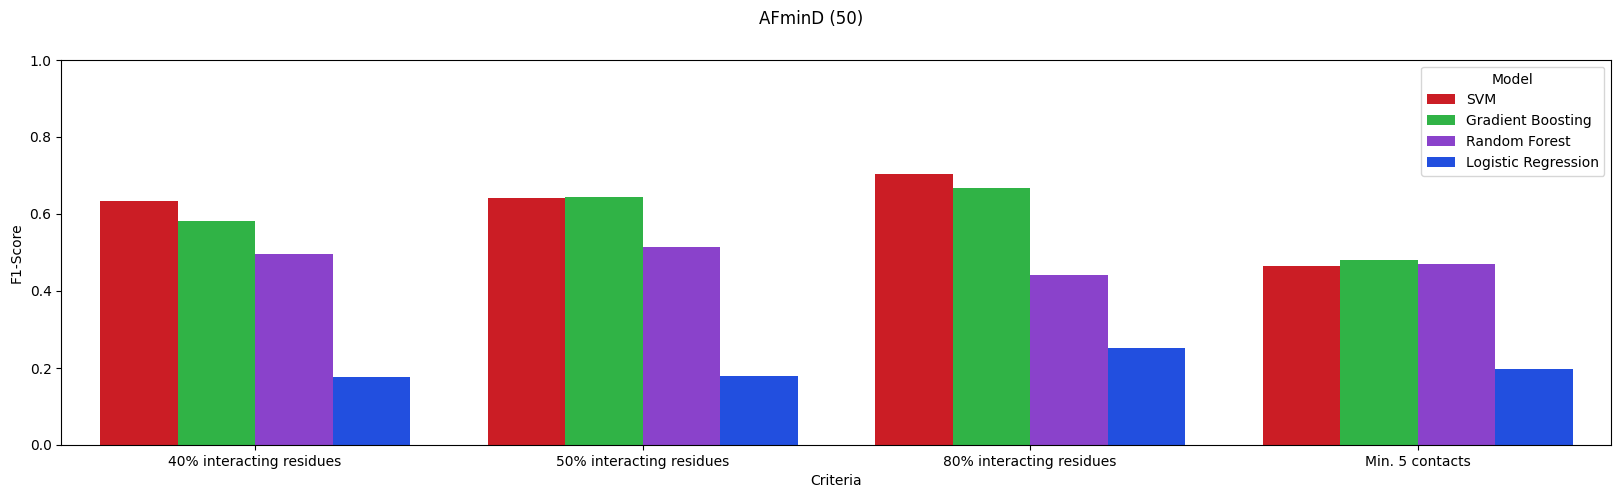

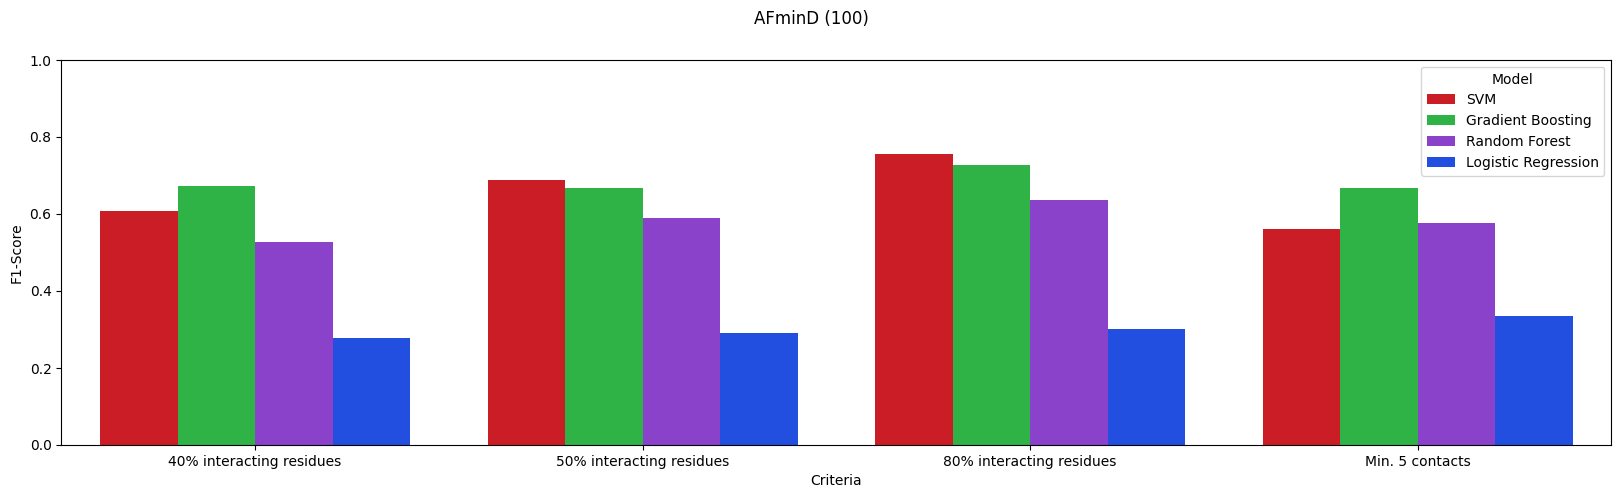

In [41]:
order = ['SVM', 'Gradient Boosting', 'Random Forest', 'Logistic Regression']
for sec in sections:
    test = classifier[(classifier['Section'] == sec) & (classifier['Criteria'].isin(criteria))]
    fig, ax = plt.subplots(figsize=(20,5))
    sns.barplot(data=test, x='Criteria', y='F1-Score', hue='Model', palette=model_colors, hue_order=order)
    ax.set_ylim(0,1)
    plt.suptitle(sec)

In [22]:
classifier_v2 = pd.read_csv("classifier_training_parallel_models_v2.tsv", sep='\t')

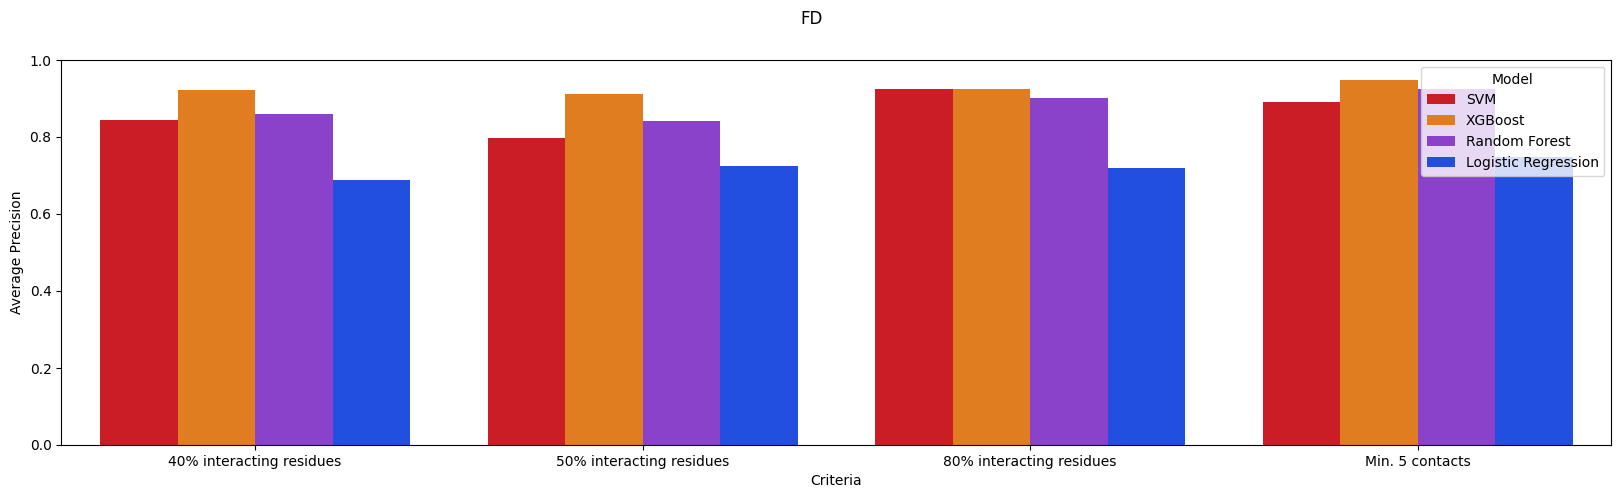

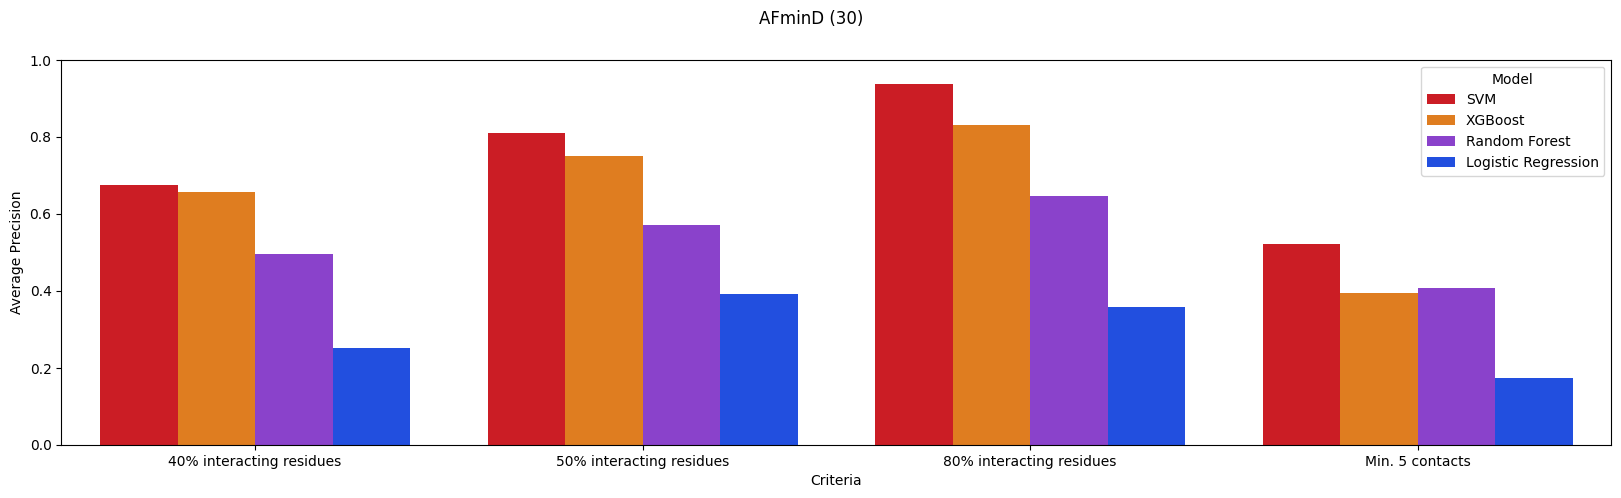

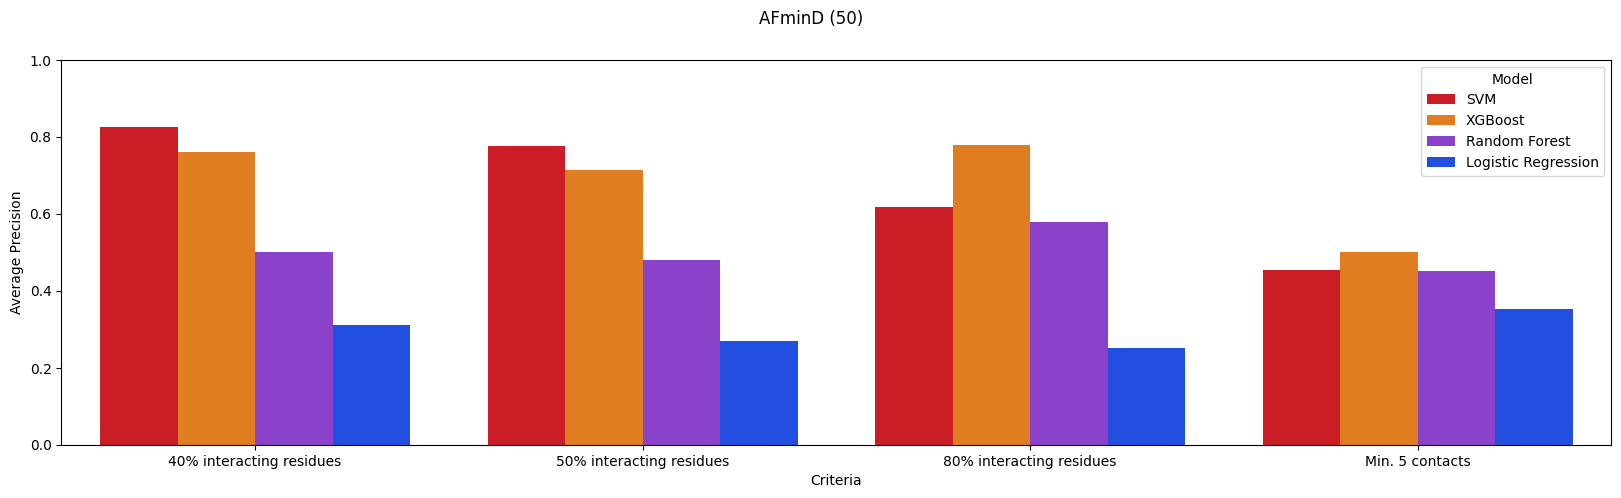

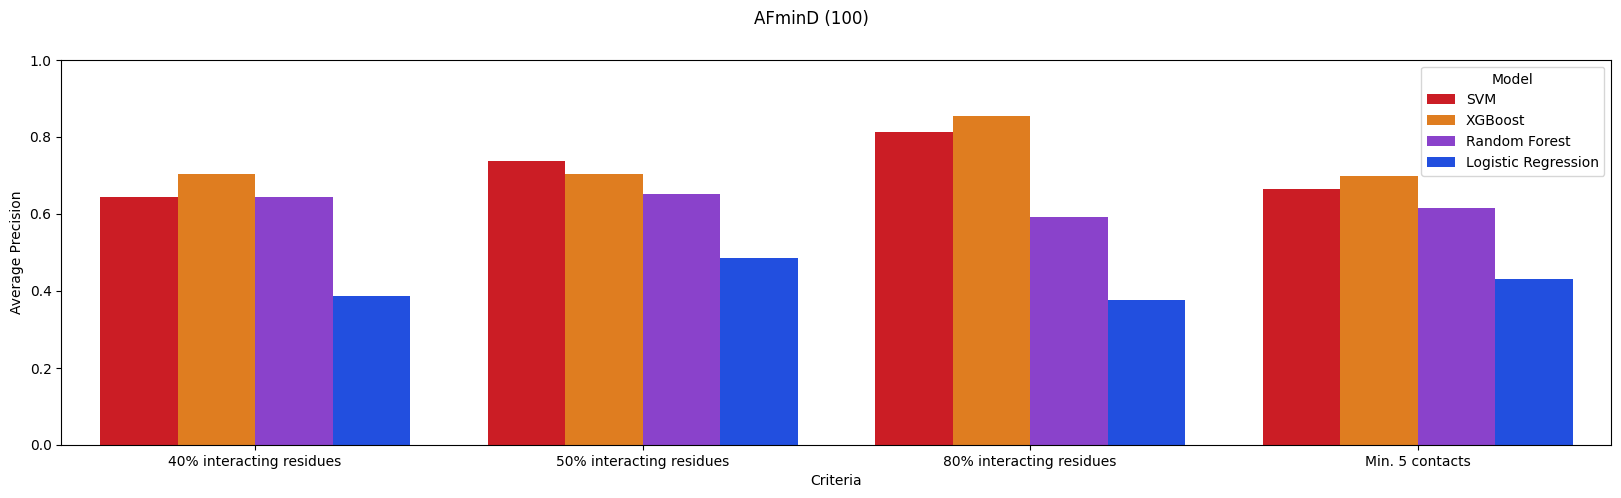

In [43]:
order = ['SVM', 'XGBoost', 'Random Forest', 'Logistic Regression']
for sec in sections:
    test = classifier_v2[(classifier_v2['Section'] == sec) & (classifier_v2['Criteria'].isin(criteria))]
    fig, ax = plt.subplots(figsize=(20,5))
    sns.barplot(data=test, x='Criteria', y='Average Precision', hue='Model', palette=model_colors, hue_order=order)
    ax.set_ylim(0,1)
    plt.suptitle(sec)

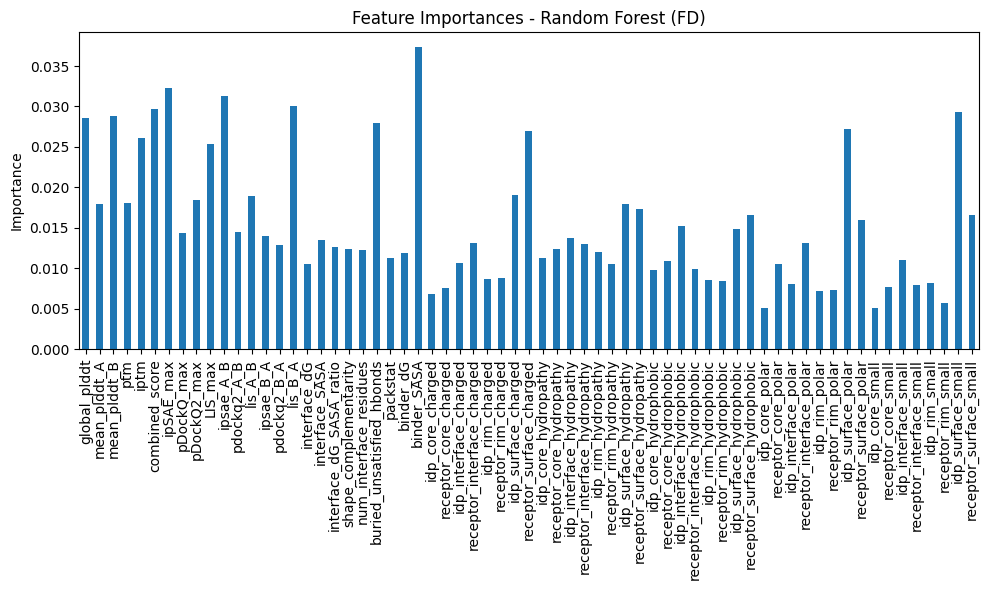

In [56]:
df = pd.read_csv("classifier_training_v4_feature_importances.tsv", sep='\t')

# Example: filter one row
row = df[
    (df["Model"] == "Random Forest") &
    (df["Section"] == "FD") &
    (df["Criteria"] == "Min. 5 contacts")
].iloc[0]

# Drop metadata columns
feature_values = row.drop(["Model", "Section", "Criteria"])

feature_values = pd.to_numeric(feature_values, errors="coerce")

plt.figure(figsize=(10, 6))
feature_values.plot(kind="bar")

plt.ylabel("Importance")
plt.title("Feature Importances - Random Forest (FD)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [44]:
classifier_v4 = pd.read_csv("classifier_training_parallel_models_v4.tsv", sep='\t')
classifier_v4

,Model,Section,Criteria,Average Precision,CV PR-AUC scores,Mean CV PR-AUC,Std CV PR-AUC,Optimal Threshold,F1 (Optimal),Precision (Optimal),...,Recall,F1-Score,AUC-ROC,Balancing Strategy,Imbalance Ratio,True Percentage,True Count,Train Size,Test Size,Low Quality Flag
0,XGBoost,AFminD (100),40% interacting residues,0.769480,[0.81242762 0.69293547 0.70722635 0.74453848 0...,0.745608,0.043252,0.625131,0.690265,0.764706,...,0.693548,0.688000,0.971868,balanced,29.822581,0.032444,310,7644,1911,False
1,SVM,AFminD (100),40% interacting residues,0.745626,[0.75983346 0.64479438 0.74401624 0.68901246 0...,0.709691,0.040824,0.439580,0.733333,0.758621,...,0.758065,0.606452,0.980879,balanced,29.822581,0.032444,310,7644,1911,False
2,Random Forest,AFminD (100),40% interacting residues,0.620222,[0.64648591 0.50450505 0.56496635 0.60981582 0...,0.594278,0.053891,0.573846,0.509434,0.613636,...,0.483871,0.526316,0.967716,balanced,29.822581,0.032444,310,7644,1911,False
3,Logistic Regression,AFminD (100),40% interacting residues,0.395972,[0.54205081 0.29316546 0.34952948 0.52479898 0...,0.430069,0.096807,0.919811,0.511628,0.492537,...,0.806452,0.277008,0.938458,balanced,29.822581,0.032444,310,7644,1911,False
4,XGBoost,AFminD (100),40% overlap interface,0.770834,[0.61565788 0.76361497 0.71465933 0.652751 0...,0.698003,0.055615,0.731993,0.693878,0.809524,...,0.678571,0.666667,0.983211,balanced,33.125000,0.029304,280,7644,1911,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Logistic Regression,FD,80% overlap interface,0.595308,[0.60395216 0.47640454 0.44370745 0.53996011 0...,0.509544,0.056460,0.725981,0.574468,0.540000,...,0.772727,0.539683,0.874120,smote,6.750000,0.129032,220,1364,341,True
108,XGBoost,FD,Min. 5 contacts,0.945767,[0.9492177 0.90878169 0.90684709 0.92481017 0...,0.916547,0.019188,0.381787,0.851986,0.825175,...,0.820896,0.856031,0.957423,none,1.544776,0.392962,670,1364,341,True
109,Random Forest,FD,Min. 5 contacts,0.911732,[0.87785032 0.88375573 0.86483691 0.90299031 0...,0.871590,0.024795,0.354537,0.801370,0.740506,...,0.694030,0.801724,0.916180,none,1.544776,0.392962,670,1364,341,True
110,SVM,FD,Min. 5 contacts,0.890471,[0.84390346 0.84764037 0.84173962 0.87883928 0...,0.841111,0.027377,0.366425,0.781022,0.764286,...,0.664179,0.763948,0.898443,none,1.544776,0.392962,670,1364,341,True
